# Data anlysis of HEK dataset

This notebook contain the data analysis of the human cell lines dataset. The analysis compared sidderent inclusions of p-ions, or SUMO fragmenting ions. The anlaysis contains;

* Importing and merging MQ outout tables msms.txt, evidence.txt
* Number of sites from sites.txt table
* Number of identified SUmoylated peptides
* Score distributions
* PSM stats including intensity coverage etc.
* Overlapping peptide sets
* Structural context from AlphaFold structures
* Motif adherence
* Benchmark results

In [126]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from upsetplot import UpSet
from matplotlib_venn import venn2

import re
from collections import Counter

plt.rcParams["font.family"] = "Arial" 

import biotite.database.entrez as entrez
import biotite.sequence as seq
from biotite.sequence import ProteinSequence
import biotite.sequence.io.fasta as fasta

import mpl_scatter_density 
from matplotlib.colors import LinearSegmentedColormap
from mpl_scatter_density import ScatterDensityArtist
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import ttest_ind
import matplotlib.patches as mpatches

import scipy.stats as stats
from statannotations.Annotator import Annotator
from scipy.stats import gaussian_kde

%load_ext autoreload

import itertools

# custom scripts 
from protein_inference import * 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
color_map = {
    '0': '#ffbc42',
    'VM': '#ffbc42',
    'SBM 0': '#ffbc42',
    'sbm_o_4': '#2ca02c', 
    'st':    '#d81159', 
    'Standard':   '#d81159', 
    'Unique Standard':    '#d81159',
    'SBM_3': '#73d2de', 
    'SBM 3': '#73d2de', 
    'MQ SBM 3': '#73d2de', 
    'MQ SBM 3 Percolator': '#b7e8ee', 
    'sbm3': '#73d2de',
    'Unique SBM 3': '#73d2de',
    'SBM_8': '#218380',
    'sbm8': '#218380',
    'SBM 8': '#218380', 
    'MSFragger': '#60435f', 
    'MSFragger 9nl Percolator': '#60435f', 
    'Unique MSFragger': '#60435f'
}

In [3]:
to_use = ['VM', 'Standard', 'SBM 3', 'SBM 3 no fdr', 'SBM 8']
custom_order = ['VM', 'Standard', 'SBM 3', 'SBM 8']

# Importing the data

In [4]:
fig_dir = '../fig_dir/'
root_dir = '../results' 
exposure = "../sites_exposure_w_FDR.txt" # AlphaFold data 
f_path = ".../uniprot-proteome_UP000005640_HUMAN_dec2020.fasta"

msfragger_folder_path = ".../MSFragger_runs"  

per_path3 = "../percolator.target.psms.txt"

In [5]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'msms.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            if parent_folder in to_use:
                df = pd.read_csv(file_path, delimiter="\t")
                
                new_columns = {}
                for col in df.columns:
                    if 'SUMO2' in col:
                        new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                        new_columns[col] = new_col_name
                
                df.rename(columns=new_columns, inplace=True)
                df['Dataset'] = parent_folder
                df['PSMId'] = df.apply(lambda x: f"{'decoy' if pd.notna(x['Reverse']) else 'target'}_0_{x['Scan number']}_{x['Raw file']}_{x['Charge']}_1", axis=1)
    
                dfs.append(df)

big_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2071719020.py:10: DtypeWarning: Columns (8,10,59,60,72,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2071719020.py:10: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2071719020.py:10: DtypeWarning: Columns (59,60,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2071719020.py:10: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [6]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if 'SUMO2_3-DVFQQQTGGSites.txt' in file:
            file_path = os.path.join(subdir, file)
            # Get the parent directory one level up
            parent_folder = os.path.basename(os.path.dirname(subdir))
            if parent_folder in to_use:
                df = pd.read_csv(file_path, delimiter="\t")
                
                new_columns = {}
                for col in df.columns:
                    if 'SUMO2' in col:
                        new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                        new_columns[col] = new_col_name
                
                df.rename(columns=new_columns, inplace=True)
                df['Dataset'] = parent_folder
    
                dfs.append(df)

sites_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/4181574581.py:10: DtypeWarning: Columns (0,1,4,5,6,17,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [7]:
sites_df['MS/MS ID'] = sites_df['MS/MS IDs'].str.split(';')
sites_df_long = sites_df.explode('MS/MS ID').reset_index(drop=True)
sites_df_long = sites_df_long.dropna(subset=['MS/MS ID'])
sites_df_long['MS/MS ID'] = sites_df_long['MS/MS ID'].astype(int)

sites_df_long_cleaned = sites_df_long.loc[sites_df_long.groupby(['MS/MS ID', 'Dataset'])['Localization prob'].idxmax()]

print(len(big_df))
big_df = big_df.merge(sites_df_long_cleaned, left_on=['id', 'Dataset'], right_on=['MS/MS ID', 'Dataset'], how='left', suffixes=('', '_sites_table'))
print(len(big_df))

1790085
1790085


In [8]:
dfs = []

for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file == 'evidence.txt':
            file_path = os.path.join(subdir, file)
            parent_folder = os.path.basename(os.path.dirname(subdir))
            
            if parent_folder in to_use:
                df = pd.read_csv(file_path, delimiter="\t")
                
                new_columns = {}
                for col in df.columns:
                    if 'SUMO2' in col:
                        new_col_name = 'SUMO2' + col.split('SUMO2', 1)[1]
                        new_columns[col] = new_col_name
                
                df.rename(columns=new_columns, inplace=True)
                df['Dataset'] = parent_folder
    
                dfs.append(df)

evi_df = pd.concat(dfs, ignore_index=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3589472447.py:10: DtypeWarning: Columns (64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3589472447.py:10: DtypeWarning: Columns (64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3589472447.py:10: DtypeWarning: Columns (64,65,72) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3589472447.py:10: DtypeWarning: Columns (64,65) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, delimiter="\t")


In [9]:
print(len(evi_df))
merged_df = evi_df.merge(big_df, left_on=['id', 'Dataset'], right_on=['Evidence ID', 'Dataset'], how='left', suffixes=('', '_msms_table'))

print(len(merged_df))

1759519
1790085


SBM 3 vs Standard (+18.4%)


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/142646621.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)


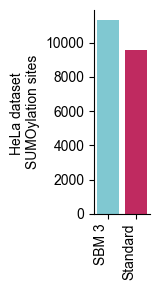

In [129]:
sites_df_sel = sites_df[sites_df['Dataset'].isin(['SBM 3', 'Standard'])]
sites_df_sel = sites_df_sel[~sites_df_sel['Leading proteins'].str.startswith(('CON', 'REV'))]

sites_counts = sites_df_sel.groupby(['Dataset']).size().reset_index(name='Count')
sites_counts = sites_counts.sort_values(by='Dataset')

count_standard = sites_counts.loc[sites_counts['Dataset'] == 'Standard', 'Count'].values[0]
count_sbm3 = sites_counts.loc[sites_counts['Dataset'] == 'SBM 3', 'Count'].values[0]
percentage_increase = ((count_sbm3 - count_standard) / count_standard) * 100

sites_counts['Dataset'] = pd.Categorical(sites_counts['Dataset'], categories=['SBM 3', 'Standard'], ordered=True)
sites_counts = sites_counts.sort_values('Dataset')

plt.figure(figsize=(1.7, 3))

palette = [color_map[ds] for ds in sites_counts['Dataset']]
ax = sns.barplot(data=sites_counts, x='Dataset', y='Count', palette=palette)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add counts on bars
#for container in ax.containers:
#    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.xticks(rotation=90, ha='right')
plt.ylabel('HeLa dataset \nSUMOylation sites')
plt.xlabel('')
print(f"SBM 3 vs Standard (+{percentage_increase:.1f}%)")
plt.tight_layout()
output_path = fig_dir + "sites.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

# Preprocessing

Here we reprocess the data for the plots and also merge datasets to get all data we need 

In [12]:
big_df = big_df[big_df['Contaminant'] != '+']
big_df['Reverse'].fillna('-', inplace=True)
big_df['Modified sequence'] = big_df['Modified sequence'].str.replace(r'st_o_SUMO2/3-DVFQQQTGG|ST_2_SUMO2/3-DVFQQQTGG|SBM_4_o_SUMO2/3-DVFQQQTGG|SBM_5_o_SUMO2/3-DVFQQQTGG|SBM_3_o_SUMO2/3-DVFQQQTGG|SBM_2_o_SUMO2/3-DVFQQQTGG|SBM_8_o_SUMO2/3-DVFQQQTGG|SBM_0_o_SUMO2/3-DVFQQQTGG', 'su', regex=True)
#big_df['Masses'] = big_df['Masses'].astype(str)
#big_df['Intensities'] = big_df['Intensities'].astype(str)
big_df['Matches'] = big_df['Matches'].astype(str)
#big_df['Masses'] = big_df['Masses'].apply(lambda x: [float(val) for val in x.split(';')])
#big_df['Intensities'] = big_df['Intensities'].apply(lambda x: [float(val) for val in x.split(';')])
big_df['Matches'] = big_df['Matches'].apply(lambda x: [val for val in x.split(';')])
big_df['Proteins'] = big_df['Proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].str.split(';')
big_df['Positions within proteins'] = big_df['Positions within proteins'].apply(
    lambda x: [int(pos) for pos in x if isinstance(x, list) and pos.strip().isdigit()] if isinstance(x, list) else []
)

In [ ]:
# Extract E, F, and R values
big_df['E'] = big_df['Raw file'].str.extract(r'_E(\d+)')
big_df['F'] = big_df['Raw file'].str.extract(r'_F(\d+)')
big_df['R'] = big_df['Raw file'].str.extract(r'_R(\d+)')
big_df[['E', 'F', 'R']] = big_df[['E', 'F', 'R']].apply(pd.to_numeric)

In [14]:
# seperate sets 
no_fdr_set = big_df[big_df['Dataset'] == 'SBM 3 no fdr']
big_df = big_df[big_df['Dataset'] != 'SBM 3 no fdr']

In [15]:
with open(f_path, "r") as file:
    fasta_file = fasta.FastaFile.read(file)

sequence_dict = fasta.get_sequences(fasta_file)
sequence_dict = {header.split('|')[1]: seq for header, seq in sequence_dict.items()}

exposure_info = pd.read_csv(exposure, delimiter=";")
exposure_info['seq'] = exposure_info['sequence'].str.extract(r'"(.*?)"')

def convert_to_number_list(str_value):
    str_value = str_value.strip('[]').replace('\n', '') #.replace(' ', ',') #.replace('.', '') 
    return [float(x) for x in str_value.split(',') if x.strip() != ''] 

def convert_to_string_list(str_value):
    str_value = str_value.strip('[]').replace('\n', '') #.replace(' ', ',')
    return [x.strip().strip("'").strip('"') for x in str_value.split(',') if x.strip() != ''] 

exposure_info['plddt'] = exposure_info['plddt'].apply(convert_to_number_list)
exposure_info['sse'] = exposure_info['sse'].apply(convert_to_string_list)

big_df = pd.merge(big_df, exposure_info, left_on='Uniprot_cannonised', right_on='outer_key', how='left') 
big_df['AF_seq'] = big_df['seq'].fillna('').astype(str)
big_df['AF_seq'] = big_df['AF_seq'].apply(lambda x: [x])

/Users/hmt128/miniconda3/lib/python3.11/site-packages/biotite/sequence/io/fasta/convert.py:248: UserWarning: ProteinSequence objects do not support selenocysteine (U), occurrences were substituted by cysteine (C)
  warnings.warn(


In [16]:
def extract_following_symbols(string, list_of_strings):
    if not isinstance(string, str): 
        return []
    
    if not isinstance(list_of_strings, list):  
        return []
    
    result = []
    for item in list_of_strings:
        if isinstance(item, str) and string in item:
            index = item.find(string)
            # Extract the two characters following the match
            following_symbols = item[index + len(string):index + len(string) + 2]
            if following_symbols.startswith('-'):
                result.append(following_symbols)
    return result

big_df['isoforms'] = big_df.apply(
    lambda row: extract_following_symbols(row['Uniprot_cannonised'], row['Proteins']), axis=1
)

def combine_string_and_list(string, list_of_strings):
    if not isinstance(string, str):  
        string = ""
    if not isinstance(list_of_strings, list):  
        return []
    
    combined = [string + item for item in list_of_strings]
    combined.insert(0, string)  
    return combined

big_df['uniprot_w_isoforms'] = big_df.apply(
    lambda row: combine_string_and_list(row['Uniprot_cannonised'], row['isoforms']), axis=1
)

big_df['isoform_seqs'] = big_df['uniprot_w_isoforms'].apply(
    lambda key_list: [str(sequence_dict.get(key, None)) for key in key_list]
)

def match_any_col2(list1, list2):
    match_results = [any(item1 in item2 for item1 in list1) for item2 in list2]
    matched_peptides = [item2 for item2, match in zip(list2, match_results) if match]

    return match_results, matched_peptides

# not 0 indexed
def find_k_positions(seq):
    return [i - 1 for i, letter in enumerate(str(seq)) if letter == 'K']

big_df['k_positions'] = big_df['AF_seq'].apply(find_k_positions)

In [77]:
all_reverse = big_df[big_df['Reverse'] == '+']
all_psms = big_df[big_df['Reverse'] == '-']
all_counts = all_psms.groupby('Dataset').size()

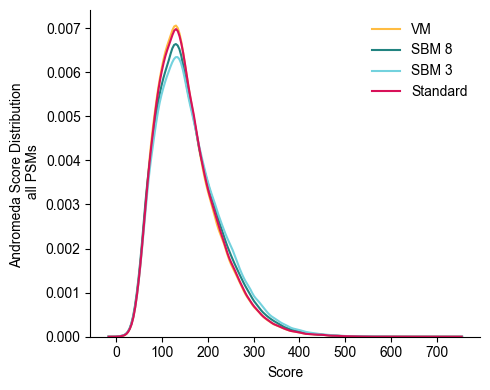

In [86]:
fig, ax = plt.subplots(figsize=(5, 4))
ax = None  # Initialize ax
for dataset in big_df['Dataset'].unique():
    ax = sns.kdeplot(
        data=big_df[big_df['Dataset'] == dataset], 
        x='Score', 
        color=color_map.get(dataset, 'grey'),  
        label=dataset, 
        common_norm=False, 
        fill=False
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlabel('Score')
plt.ylabel('Andromeda Score Distribution \n all PSMs')
plt.title('')
plt.tight_layout()
legend = plt.legend(loc='upper right', frameon=True)
legend.get_frame().set_facecolor('white')  
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0) 

file_path = fig_dir + "dist.pdf"
plt.savefig(file_path, transparent=True)

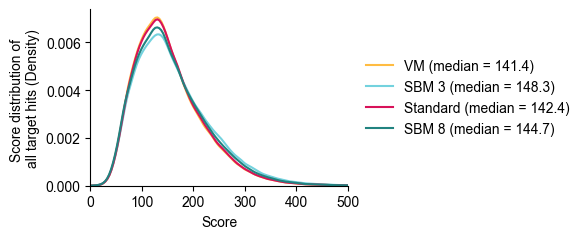

In [88]:
fig, ax = plt.subplots(figsize=(6, 2.5))

median_labels = []

for dataset in all_psms['Dataset'].unique():
    subset = all_psms[all_psms['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    median_labels.append(label_with_median)

    sns.kdeplot(
        data=subset,
        x='Score',
        ax=ax,
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        color=color_map.get(dataset, 'grey') 
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Score distribution of \nall target hits (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

plt.tight_layout()
legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

plt.tight_layout()
file_path = fig_dir + "score_kde_all_target.pdf"
plt.savefig(file_path, transparent=True)


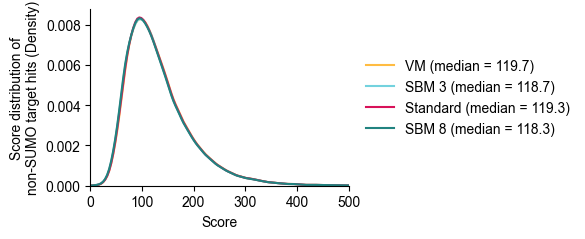

In [89]:
fig, ax = plt.subplots(figsize=(6, 2.5))

median_labels = []

all_nosumo = all_psms[all_psms['SUMO2/3-DVFQQQTGG'] == 0]

for dataset in all_nosumo['Dataset'].unique():
    subset = all_nosumo[all_nosumo['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    median_labels.append(label_with_median)

    sns.kdeplot(
        data=subset,
        x='Score',
        ax=ax,
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        color=color_map.get(dataset, 'grey')  # Fallback color
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Score distribution of\nnon-SUMO target hits (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

# Layout & legend
plt.tight_layout()
legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

plt.tight_layout()
file_path = fig_dir + "score_kde_all_nonsumo.pdf"
plt.savefig(file_path, transparent=True)


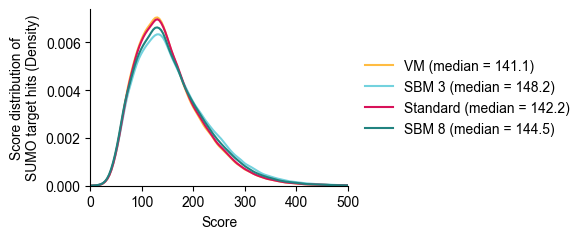

In [91]:
fig, ax = plt.subplots(figsize=(6, 2.5))

median_labels = []

all_sumo = all_psms[all_psms['SUMO2/3-DVFQQQTGG'] <= 1]

for dataset in all_sumo['Dataset'].unique():
    subset = all_sumo[all_sumo['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    median_labels.append(label_with_median)

    sns.kdeplot(
        data=subset,
        x='Score',
        ax=ax,
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        color=color_map.get(dataset, 'grey')  # Fallback color
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Score distribution of\nSUMO target hits (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

plt.tight_layout()
legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

plt.tight_layout()
file_path = fig_dir + "score_kde_target_sumo.pdf"
plt.savefig(file_path, transparent=True)

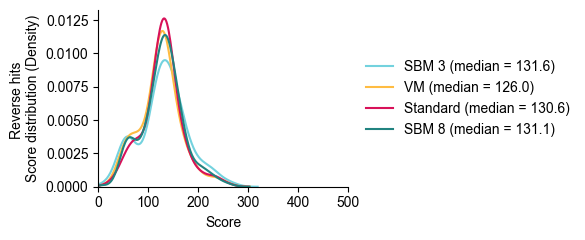

In [82]:
fig, ax = plt.subplots(figsize=(6, 2.5))  

median_labels = []

for dataset in all_reverse['Dataset'].unique():
    subset = all_reverse[all_reverse['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    median_labels.append(label_with_median)

    sns.kdeplot(
        data=subset,
        x='Score',
        color=color_map.get(dataset, 'grey'),
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        common_norm=False,
        ax=ax
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Reverse hits \nScore distribution (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

plt.tight_layout()

file_path = fig_dir + "reverse_hit_dist.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')

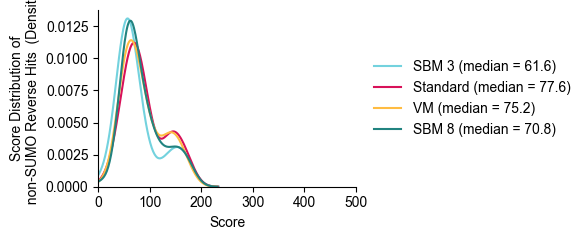

In [92]:
all_reverse_nosumo = all_reverse[all_reverse['SUMO2/3-DVFQQQTGG'] == 0]

fig, ax = plt.subplots(figsize=(6, 2.5)) 

for dataset in all_reverse_nosumo['Dataset'].unique():
    subset = all_reverse_nosumo[all_reverse_nosumo['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    
    sns.kdeplot(
        data=subset,
        x='Score',
        ax=ax,
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        color=color_map.get(dataset, 'grey') 
    )

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Score Distribution of\n non-SUMO Reverse Hits  (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

plt.tight_layout()  

file_path = fig_dir + "non_sumoreverse_hit_dist_kde.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')


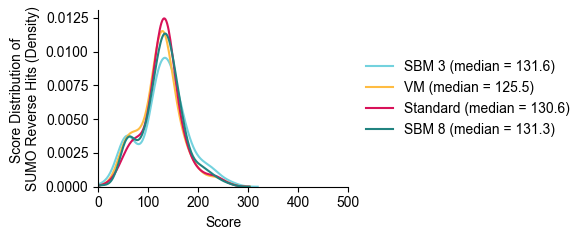

In [93]:
all_reverse_sumo = all_reverse[(all_reverse['SUMO2/3-DVFQQQTGG'] <= 1)]

fig, ax = plt.subplots(figsize=(6, 2.5)) 

for dataset in all_reverse_sumo['Dataset'].unique():
    subset = all_reverse_sumo[all_reverse_sumo['Dataset'] == dataset]
    median_score = subset['Score'].median()
    label_with_median = f"{dataset} (median = {median_score:.1f})"
    
    sns.kdeplot(
        data=subset,
        x='Score',
        ax=ax,
        label=label_with_median,
        fill=False,
        alpha=1,
        linewidth=1.5,
        color=color_map.get(dataset, 'grey'),
        common_norm=False
    )

# Clean up axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Score')
ax.set_ylabel('Score Distribution of \nSUMO Reverse Hits (Density)')
ax.set_xlim(0, 500)
ax.set_title('')

# External legend
legend = ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)
legend.get_frame().set_linewidth(0)

# Adjust layout
plt.tight_layout()  # Leave space for legend

# Save
file_path = fig_dir + "SUMO_reverse_hit_dist.pdf"
plt.savefig(file_path, transparent=True, bbox_inches='tight')


# Seperating data into diffrent sets

In [85]:
big_df = big_df.sort_values(by="Score", ascending=False)

df_sumo = big_df[(big_df['SUMO2/3-DVFQQQTGG'] == 1)]
df_no_sumo = big_df[(big_df['SUMO2/3-DVFQQQTGG'] == 0)] 
df_sumo_more = big_df[(big_df['SUMO2/3-DVFQQQTGG'] > 1)] 

df_sumo_unique = df_sumo.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')).reset_index(drop=True)
df_unique = all_psms.groupby('Dataset').apply(lambda x: x.drop_duplicates(subset=['Modified sequence'], keep='first')).reset_index(drop=True)

all_unique_counts = df_unique.groupby('Dataset').size()

In [25]:
filtered_big_df_sumo = df_sumo[df_sumo['Reverse'] != '+']
filtered_counts = filtered_big_df_sumo.groupby('Dataset').size()

filtered_big_df_moresuno = df_sumo_more[df_sumo_more['Reverse'] != '+']
filtered_counts_moresumo = filtered_big_df_moresuno.groupby('Dataset').size()

filtered_big_df_unique = df_sumo_unique[df_sumo_unique['Reverse'] != '+']
filtered_counts_unique = filtered_big_df_unique.groupby('Dataset').size()

filtered_big_df_no_sumo = df_no_sumo[df_no_sumo['Reverse'] != '+']
filtered_counts_no_sumo = filtered_big_df_no_sumo.groupby('Dataset').size()

filtered_big_df_unique_peps = df_unique[df_unique['Reverse'] != '+']
filtered_counts_unique_peps = filtered_big_df_unique_peps.groupby('Dataset').size()

In [26]:
median_per_group = df_sumo.groupby('Dataset')['Score'].median()
print(median_per_group)

Dataset
SBM 3       182.15
SBM 8       177.04
Standard    169.09
VM          168.24
Name: Score, dtype: float64


In [27]:
median_per_group = df_sumo.groupby('Dataset')['Number of matches'].median()
print(median_per_group)

Dataset
SBM 3       45.0
SBM 8       47.0
Standard    40.0
VM          38.0
Name: Number of matches, dtype: float64


# Visualisations

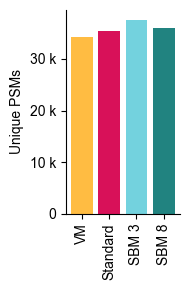

In [59]:
fig, ax = plt.subplots(figsize=(2, 3))

sorted_counts = all_unique_counts.reindex(custom_order)


bars = ax.bar(
    sorted_counts.index,
    sorted_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in sorted_counts.index]
)

ax.set_xticks(range(len(sorted_counts.index)))
ax.set_xticklabels(sorted_counts.index, rotation=90)
ax.set_xlabel('')
ax.set_ylabel('Unique PSMs')
ax.set_title('')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_unique_psms.pdf"
plt.savefig(file_path, transparent=True)
plt.show() 

Dataset
VM          217745
Standard    226671
SBM 3       242272
SBM 8       229452
dtype: int64


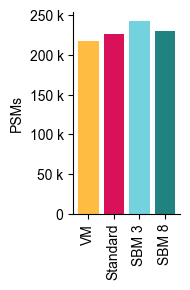

In [62]:
custom_order = [name for name in custom_order if name in all_counts.index]
ordered_counts = all_counts.reindex(custom_order)

print(ordered_counts)

fig, ax_psms = plt.subplots(figsize=(2, 3))

psm_bars = ax_psms.bar(
    ordered_counts.index,
    ordered_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in ordered_counts.index]
)


ax_psms.set_xlabel('')
ax_psms.set_ylabel('PSMs')
ax_psms.set_title('')
ax_psms.set_xticks(range(len(ordered_counts.index)))
ax_psms.set_xticklabels(ordered_counts.index, rotation=90)
ax_psms.spines['right'].set_visible(False)
ax_psms.spines['top'].set_visible(False)
ax_psms.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
output_path = fig_dir + "nr_psms.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

# For non SUMOylated peptides

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3610484576.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


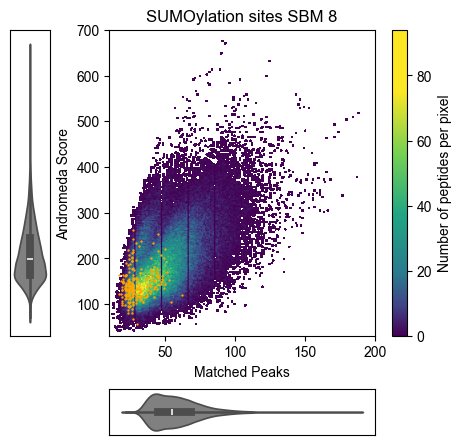

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3610484576.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


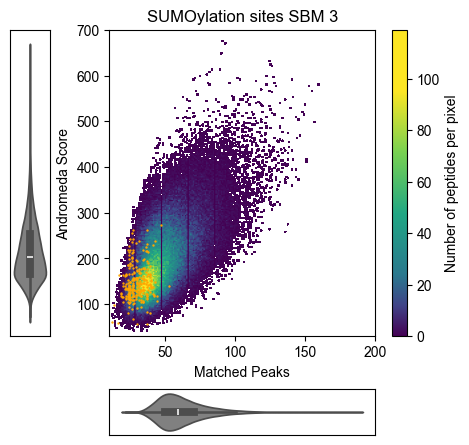

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3610484576.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


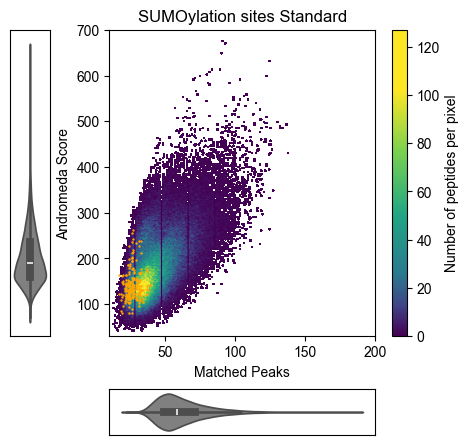

/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/Users/hmt128/miniconda3/lib/python3.11/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3610484576.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


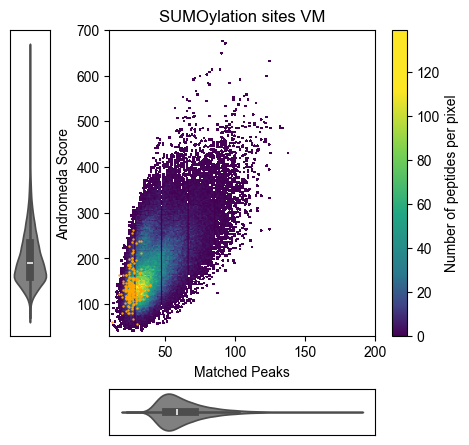

In [31]:
num_levels = 50000

white_viridis = LinearSegmentedColormap.from_list('white_viridis', [
    (0, '#ffffff'),
    (1e-20, '#440053'),
    (0.1, '#404388'),
    (0.2, '#2a788e'),
    (0.4, '#21a784'),
    (0.6, '#78d151'),
    (0.8, '#fde624'),
    (1, '#fde624'),
], N=num_levels)

def using_mpl_scatter_density(fig, x, y, color, filename=None, title=None, dpi=72):
    fig = plt.figure(figsize=(4.5, 4))  
    ax = fig.add_subplot(1, 1, 1, projection='scatter_density')
    
    density = ax.scatter_density(x[color == 'default'], y[color == 'default'], cmap=white_viridis)

    fig.colorbar(density, label='Number of peptides per pixel', ax=ax)  
    ax.scatter(x[color == 'orange'], y[color == 'orange'], color='orange', s=0.5, alpha=1, label='Reverse')
    
    ax.set_xlabel('Matched Peaks')
    ax.set_ylabel('Andromeda Score')
    ax.set_xlim(10, 200) 
    ax.set_ylim(30, 700)
    
    if title:
        ax.set_title(title)
    
    ax_xbox = inset_axes(ax, width="100%", height="15%", loc='upper center', bbox_to_anchor=(0, -1.15, 1, 1), bbox_transform=ax.transAxes)
    sns.violinplot(x=x, ax=ax_xbox, color='gray')
    ax_xbox.set_xticks([])
    ax_xbox.set_yticks([])
    ax_xbox.set_xlabel('')
    ax_xbox.set_ylabel('')
    
    ax_ybox = inset_axes(ax, width="15%", height="100%", loc='center left', bbox_to_anchor=(-0.4, 0, 1, 1), bbox_transform=ax.transAxes)
    sns.violinplot(y=y, ax=ax_ybox, color='gray', orient='v')
    ax_ybox.set_xticks([])
    ax_ybox.set_yticks([])
    ax_ybox.set_xlabel('')
    ax_ybox.set_ylabel('')

    plt.tight_layout()
    plt.legend(frameon=False, loc='lower right')

    if filename: 
        plt.savefig(filename, bbox_inches='tight', dpi=dpi, transparent=True) # 
    
    plt.show()

group_column = 'Dataset'

for category in df_sumo[group_column].unique():
    category_df = df_sumo[df_sumo[group_column] == category]
    
    x = category_df['Number of matches'].values
    y = category_df['Score'].values
    reverse_flag = category_df['Reverse'].values
    
    color = np.where(reverse_flag == '+', 'orange', 'default')

    output_file = os.path.join(fig_dir, f"scatter_density_{category}.pdf")

    using_mpl_scatter_density(fig, x, y, color, output_file, f"SUMOylation sites {category}")


# For SUMOylated peptides

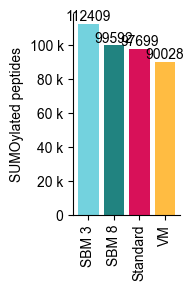

In [53]:
fig, ax = plt.subplots(figsize=(2, 3))
bars = ax.bar(filtered_counts.index, filtered_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts.index]
)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts.index) 
ax.set_xticklabels(filtered_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_sumoylated_peptides.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

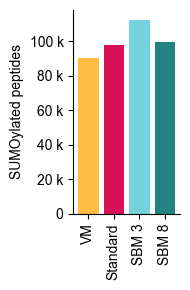

In [34]:
custom_order = [name for name in custom_order if name in filtered_counts.index]
ordered_filtered_counts = filtered_counts.reindex(custom_order)

# Create figure and axis
fig, ax_sumo = plt.subplots(figsize=(2, 3))

# Plot bars with colors from color_map
sumo_bars = ax_sumo.bar(
    ordered_filtered_counts.index,
    ordered_filtered_counts.values,
    color=[color_map.get(dataset, 'grey') for dataset in ordered_filtered_counts.index]
)

# Optional: annotate bar heights
# for bar in sumo_bars:
#     height = bar.get_height()
#     ax_sumo.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax_sumo.set_xlabel('')
ax_sumo.set_ylabel('SUMOylated peptides')
ax_sumo.set_title('')
ax_sumo.set_xticks(range(len(ordered_filtered_counts.index)))
ax_sumo.set_xticklabels(ordered_filtered_counts.index, rotation=90)

ax_sumo.spines['right'].set_visible(False)
ax_sumo.spines['top'].set_visible(False)
ax_sumo.yaxis.set_major_formatter(ticker.EngFormatter())

plt.tight_layout()
output_path = fig_dir + "nr_sumoylated_peptides.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

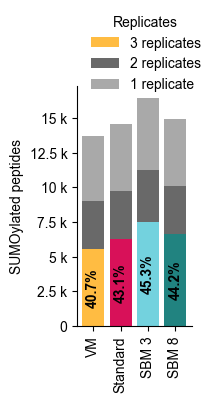

In [35]:
df_sumo_filtered = df_sumo[df_sumo['Dataset'].isin(custom_order)]
df_sumo_filtered['Dataset'] = pd.Categorical(df_sumo_filtered['Dataset'], categories=custom_order, ordered=True)
df_sumo_filtered = df_sumo_filtered.sort_values('Dataset')

grey_shades = ['#D3D3D3', '#A9A9A9', '#696969']
fig, ax_completeness = plt.subplots(figsize=(2, 4.5))
dataset_positions = np.arange(len(custom_order))

bar_width = 0.8

for i, dataset in enumerate(custom_order):
    data = df_sumo_filtered[df_sumo_filtered['Dataset'] == dataset]
    replicate_counts = data.groupby('Modified sequence')['R'].nunique()
    replicate_distribution = replicate_counts.value_counts().reindex([1, 2, 3], fill_value=0)
    bottom = 0
    total_sequences = replicate_distribution.sum()
    color_3_replicates = color_map.get(dataset, 'grey')

    if replicate_distribution[3] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[3], color=color_3_replicates, bottom=bottom, width=bar_width, edgecolor=None)
        ax_completeness.text(dataset_positions[i], bottom + replicate_distribution[3] / 2, f'{(replicate_distribution[3] / total_sequences) * 100:.1f}%',
                             ha='center', va='center', fontsize=10, color='black', fontweight='bold', rotation=90)
        bottom += replicate_distribution[3]

    if replicate_distribution[2] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[2], color=grey_shades[2], bottom=bottom, width=bar_width, edgecolor=None)
        bottom += replicate_distribution[2]

    if replicate_distribution[1] > 0:
        ax_completeness.bar(dataset_positions[i], replicate_distribution[1], color=grey_shades[1], bottom=bottom, width=bar_width, edgecolor=None)
        bottom += replicate_distribution[1]

ax_completeness.set_xticks(dataset_positions)
ax_completeness.set_xticklabels(custom_order, rotation=90)
ax_completeness.yaxis.set_major_formatter(ticker.EngFormatter())
ax_completeness.set_xlabel("")
ax_completeness.set_ylabel("SUMOylated peptides")
ax_completeness.spines['top'].set_visible(False)
ax_completeness.spines['right'].set_visible(False)
ax_completeness.legend(
    ['3 replicates', '2 replicates', '1 replicate'],
    loc="upper center",
    title="Replicates",
    frameon=False,
    bbox_to_anchor=(0.6, 1.35)
)

plt.tight_layout()
output_path = fig_dir + "data_completeness.pdf"
plt.savefig(output_path, transparent=True)
plt.show()


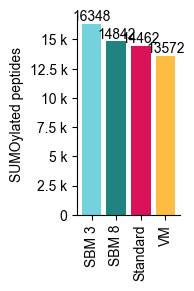

In [36]:
fig, ax = plt.subplots(figsize=(2, 3))
bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

for bar in bars_un:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom')

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
#ax.set_ylim(0, 9000)
ax.set_xticklabels(filtered_counts_unique.index, rotation=90) # rotation=45,  
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()

file_path = fig_dir + "unique_sumo_peptides.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [37]:
def get_significance_stars(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

In [38]:
import sys
min_display_p = sys.float_info.min 

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2001625034.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin.set_xticklabels(custom_order, rotation=90)


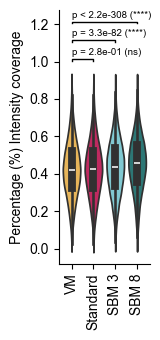

In [39]:
combined_data_int = filtered_big_df_sumo.pivot(columns='Dataset', values='Intensity coverage')
combined_data_int = combined_data_int[custom_order]

vm_data = combined_data_int['VM'].dropna()
p_values = {}

for other_group in ['Standard', 'SBM 3', 'SBM 8']:
    other_data = combined_data_int[other_group].dropna()
    stat, p = ttest_ind(vm_data, other_data, equal_var=False)
    p_values[( 'VM', other_group )] = p

fig, ax_violin = plt.subplots(figsize=(1.7, 3.5))
sns.violinplot(data=combined_data_int, ax=ax_violin, palette=[color_map[ds] for ds in custom_order])
ax_violin.set_title('')
ax_violin.set_xlabel('')
ax_violin.set_ylabel('Percentage (%) Intensity coverage')
ax_violin.spines['right'].set_visible(False)
ax_violin.spines['top'].set_visible(False)
ax_violin.set_xticklabels(custom_order, rotation=90)
positions = {label: idx for idx, label in enumerate(custom_order)}
y_max = combined_data_int.max().max()
stagger_heights = [0.1, 0.2, 0.3] 

for i, (group1, group2) in enumerate(p_values.keys()):
    p = p_values[(group1, group2)]
    x1 = positions[group1]
    x2 = positions[group2]
    y = y_max + stagger_heights[i]
    h = 0.01  
    col = 'black'

    ax_violin.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)

    if p < min_display_p:
        p_display = f"p < {min_display_p:.1e}" 
    else:
        p_display = f"p = {p:.1e}"

    p_text = f"{p_display} ({get_significance_stars(p)})"
    ax_violin.text(x1, y + h + 0.01, p_text, ha='left', va='bottom', color=col, fontsize=7)

plt.tight_layout()
output_path = fig_dir + "intensity_coverage_with_pvalues.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

Statistical Summary for Intensity Coverage (%):

                 n  Q1 (25%)  Median (50%)  Q3 (75%)  Mean
Dataset                                                   
VM         90028.0      0.32          0.42      0.52  0.42
Standard   97699.0      0.32          0.42      0.52  0.42
SBM 3     112409.0      0.34          0.44      0.54  0.44
SBM 8      99592.0      0.35          0.46      0.55  0.45


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/705593756.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin.set_xticklabels(custom_order, rotation=90)


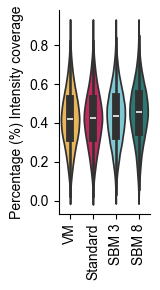

In [40]:
combined_data_int = filtered_big_df_sumo.pivot(columns='Dataset', values='Intensity coverage')
combined_data_int = combined_data_int[custom_order]

summary_stats = combined_data_int.describe().T[
    ['count', '25%', '50%', '75%', 'mean']
].rename(columns={
    'count': 'n',
    '25%': 'Q1 (25%)',
    '50%': 'Median (50%)',
    '75%': 'Q3 (75%)',
    'mean': 'Mean'
})

summary_stats = summary_stats.round(2)

print("Statistical Summary for Intensity Coverage (%):\n")
print(summary_stats)


fig, ax_violin = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_int, ax=ax_violin, palette=[color_map[ds] for ds in custom_order])
ax_violin.set_title('')
ax_violin.set_xlabel('')
ax_violin.set_ylabel('Percentage (%) Intensity coverage')
ax_violin.spines['right'].set_visible(False)
ax_violin.spines['top'].set_visible(False)
ax_violin.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "intensity_coverage.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

Statistical Summary for Peak Coverage (%):

                 n  Q1 (25%)  Median (50%)  Q3 (75%)  Mean
Dataset                                                   
VM         90028.0      0.13          0.15      0.18  0.16
Standard   97699.0      0.14          0.16      0.19  0.17
SBM 3     112409.0      0.15          0.18      0.21  0.18
SBM 8      99592.0      0.15          0.19      0.23  0.19


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2375366106.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_peak.set_xticklabels(custom_order, rotation=90)


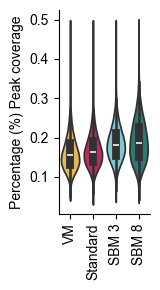

In [41]:
combined_data_peak = filtered_big_df_sumo.pivot(columns='Dataset', values='Peak coverage')
combined_data_peak = combined_data_peak[custom_order]

summary_stats = combined_data_peak.describe().T[
    ['count', '25%', '50%', '75%', 'mean']
].rename(columns={
    'count': 'n',
    '25%': 'Q1 (25%)',
    '50%': 'Median (50%)',
    '75%': 'Q3 (75%)',
    'mean': 'Mean'
})

summary_stats = summary_stats.round(2)

print("Statistical Summary for Peak Coverage (%):\n")
print(summary_stats)

fig, ax_violin_peak = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_peak, ax=ax_violin_peak, palette=[color_map[ds] for ds in custom_order])
ax_violin_peak.set_title('')
ax_violin_peak.set_xlabel('')
ax_violin_peak.set_ylabel('Percentage (%) Peak coverage')
ax_violin_peak.spines['right'].set_visible(False)
ax_violin_peak.spines['top'].set_visible(False)
ax_violin_peak.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "peak_coverage.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/1713240311.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_peak.set_xticklabels(custom_order, rotation=90)


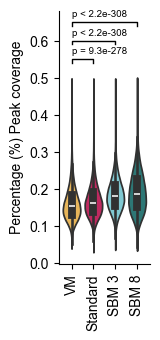

In [42]:
vm_peak = combined_data_peak['VM'].dropna()
p_values_peak = {}

for other_group in ['Standard', 'SBM 3', 'SBM 8']:
    other_data = combined_data_peak[other_group].dropna()
    stat, p = ttest_ind(vm_peak, other_data, equal_var=False)
    p_values_peak[('VM', other_group)] = p

fig, ax_violin_peak = plt.subplots(figsize=(1.7, 3.5))
sns.violinplot(data=combined_data_peak, ax=ax_violin_peak, palette=[color_map[ds] for ds in custom_order])
ax_violin_peak.set_title('')
ax_violin_peak.set_xlabel('')
ax_violin_peak.set_ylabel('Percentage (%) Peak coverage')
ax_violin_peak.spines['right'].set_visible(False)
ax_violin_peak.spines['top'].set_visible(False)
ax_violin_peak.set_xticklabels(custom_order, rotation=90)
positions = {label: idx for idx, label in enumerate(custom_order)}
y_max_peak = combined_data_peak.max().max()
stagger_heights = [0.05, 0.1, 0.15]

for i, (group1, group2) in enumerate(p_values_peak.keys()):
    p = p_values_peak[(group1, group2)]
    x1 = positions[group1]
    x2 = positions[group2]
    y = y_max_peak + stagger_heights[i]
    h = 0.01 
    col = 'black'

    ax_violin_peak.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)

    if p < min_display_p:
        p_display = f"p < {min_display_p:.1e}" 
    else:
        p_display = f"p = {p:.1e}"
    ax_violin_peak.text(x1, y + h + 0.01, p_display, ha='left', va='bottom', color=col, fontsize=7)

plt.tight_layout()
output_path = fig_dir + "peak_coverage_with_pvalues.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

Statistical Summary for matched peaks :

                 n  Q1 (25%)  Median (50%)  Q3 (75%)   Mean
Dataset                                                    
VM         90028.0      32.0          38.0      48.0  41.53
Standard   97699.0      33.0          40.0      50.0  43.35
SBM 3     112409.0      37.0          45.0      55.0  47.70
SBM 8      99592.0      36.0          47.0      61.0  50.14


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/347595407.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_peak.set_xticklabels(custom_order, rotation=90)


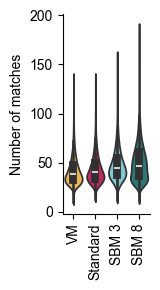

In [43]:
combined_data_m = filtered_big_df_sumo.pivot(columns='Dataset', values='Number of matches')
combined_data_m = combined_data_m[custom_order]

summary_stats = combined_data_m.describe().T[
    ['count', '25%', '50%', '75%', 'mean']
].rename(columns={
    'count': 'n',
    '25%': 'Q1 (25%)',
    '50%': 'Median (50%)',
    '75%': 'Q3 (75%)',
    'mean': 'Mean'
})

summary_stats = summary_stats.round(2)

print("Statistical Summary for matched peaks :\n")
print(summary_stats)


fig, ax_violin_peak = plt.subplots(figsize=(1.7, 3))
sns.violinplot(data=combined_data_m, ax=ax_violin_peak, palette=[color_map[ds] for ds in custom_order])
ax_violin_peak.set_title('')
ax_violin_peak.set_xlabel('')
ax_violin_peak.set_ylabel('Number of matches')
ax_violin_peak.spines['right'].set_visible(False)
ax_violin_peak.spines['top'].set_visible(False)
ax_violin_peak.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "Nr_matches.pdf"
plt.savefig(output_path, transparent=True)
plt.show()


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/935148357.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_violin_m.set_xticklabels(custom_order, rotation=90)


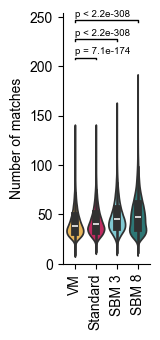

In [44]:
vm_m = combined_data_m['VM'].dropna()
p_values_m = {}

for other_group in ['Standard', 'SBM 3', 'SBM 8']:
    other_data = combined_data_m[other_group].dropna()
    stat, p = ttest_ind(vm_m, other_data, equal_var=False)
    p_values_m[('VM', other_group)] = p

fig, ax_violin_m = plt.subplots(figsize=(1.7, 3.5))
sns.violinplot(data=combined_data_m, ax=ax_violin_m, palette=[color_map[ds] for ds in custom_order])
ax_violin_m.set_title('')
ax_violin_m.set_xlabel('')
ax_violin_m.set_ylabel('Number of matches')
ax_violin_m.spines['right'].set_visible(False)
ax_violin_m.spines['top'].set_visible(False)
ax_violin_m.set_xticklabels(custom_order, rotation=90)

positions = {label: idx for idx, label in enumerate(custom_order)}
y_max_m = combined_data_m.max().max()
stagger_heights = [0.1 * y_max_m, 0.2 * y_max_m, 0.3 * y_max_m]

for i, (group1, group2) in enumerate(p_values_m.keys()):
    p = p_values_m[(group1, group2)]
    x1 = positions[group1]
    x2 = positions[group2]
    y = y_max_m + stagger_heights[i]
    h = 0.01 * y_max_m  # height of the line
    col = 'black'

    ax_violin_m.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1, c=col)

    if p < min_display_p:
        p_display = f"p < {min_display_p:.1e}" 
    else:
        p_display = f"p = {p:.1e}"
    ax_violin_m.text(x1, y + h + 0.01 * y_max_m, p_display, ha='left', va='bottom', color=col, fontsize=7)

ax_violin_m.set_ylim(0, y_max_m + max(stagger_heights) + 0.05 * y_max_m)
plt.tight_layout()
output_path = fig_dir + "Nr_matches_with_pvalues.pdf"
plt.savefig(output_path, transparent=True)
plt.show()


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3047137240.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing,
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3047137240.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_missing.set_xticklabels(custom_order, rotation=90)


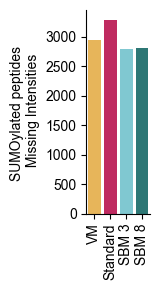

In [45]:
missing_values_by_dataset = filtered_big_df_sumo.groupby('Dataset')['Intensity'].apply(lambda x: x.isna().sum())
missing_values_by_dataset = missing_values_by_dataset[custom_order]

fig, ax_missing = plt.subplots(figsize=(1.7, 3))
sns.barplot(x=missing_values_by_dataset.index, y=missing_values_by_dataset.values, ax=ax_missing, 
            palette=[color_map[ds] for ds in custom_order])

ax_missing.set_xlabel('')
ax_missing.set_ylabel('SUMOylated peptides \n Missing Intensities')
ax_missing.set_title('')
ax_missing.spines['right'].set_visible(False)
ax_missing.spines['top'].set_visible(False)
ax_missing.set_xticklabels(custom_order, rotation=90)

plt.tight_layout()
output_path = fig_dir + "missing_values_sumosites.pdf"
plt.savefig(output_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/731910114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_big_df_sumo['scan_modseq'] =  filtered_big_df_sumo['Scan number'].astype(str) + "_" + filtered_big_df_sumo['Modified sequence']


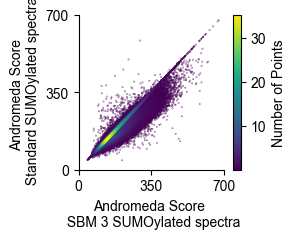

In [46]:
filtered_big_df_sumo['scan_modseq'] =  filtered_big_df_sumo['Scan number'].astype(str) + "_" + filtered_big_df_sumo['Modified sequence'] 

sbm_3_df = filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == 'SBM 3']
st_df = filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == 'Standard']
sbm_3_seqs = set(sbm_3_df["scan_modseq"])
st_seqs = set(st_df["scan_modseq"])

common_seqs = sbm_3_seqs & st_seqs

sbm_3_filtered = sbm_3_df[sbm_3_df["scan_modseq"].isin(common_seqs)]
st_filtered = st_df[st_df["scan_modseq"].isin(common_seqs)]

merged_df = sbm_3_filtered.merge(st_filtered, on="scan_modseq", suffixes=('_sbm3', '_st'))

x = merged_df["Score_sbm3"].values
y = merged_df["Score_st"].values

xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy) * len(x) 

idx = density.argsort()
x, y, density = x[idx], y[idx], density[idx]
fig, ax = plt.subplots(figsize=(3, 2.5))
sc = ax.scatter(x, y, c=density, cmap='viridis', alpha=1, s=0.05)

min_val = 0
max_val = 700
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ticks = np.linspace(min_val, max_val, num=3) 
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlabel("Andromeda Score \n SBM 3 SUMOylated spectra")
ax.set_ylabel("Andromeda Score \n Standard SUMOylated spectra")
ax.set_title("")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Number of Points") 

plt.tight_layout()
file_path = fig_dir + "mod_sec_score_sumo_peptides.pdf"
plt.savefig(file_path, format='pdf', transparent=True)
plt.show()

In [47]:
# plotting the avergae scores
x.mean()

200.83283219033552

In [48]:
y.mean()

183.89962839206584

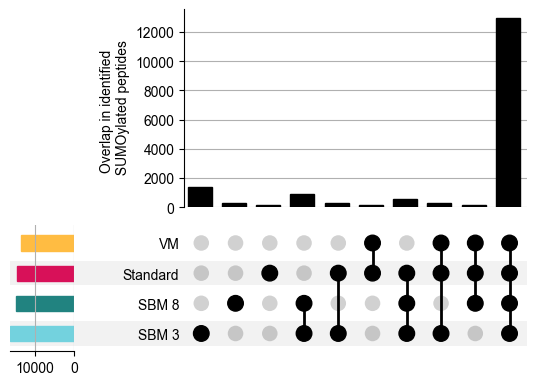

In [49]:
dataset_names = filtered_big_df_sumo['Dataset'].unique()

dataset_sequence_sets = {
    name: set(filtered_big_df_sumo[filtered_big_df_sumo['Dataset'] == name]['Modified sequence'])
    for name in dataset_names
}

all_sequences = set().union(*dataset_sequence_sets.values())

data_speps = []
for sequence in all_sequences:
    row = [sequence in sequence_set for sequence_set in dataset_sequence_sets.values()]
    row.append(sequence)
    data_speps.append(row)



column_names = list(dataset_sequence_sets.keys()) + ['Modified sequence']

df_overlap = pd.DataFrame(data_speps, columns=column_names)

df_overlap.set_index(column_names[:-1], inplace=True)

upset = UpSet(
    df_overlap,
    subset_size="count",
    min_subset_size=100,
    show_counts=False
)

for category in color_map: 
    upset.style_categories(
        [category],
        bar_facecolor=color_map.get(category, 'grey'),
        bar_edgecolor=None
    )

ax_dict = upset.plot() 
ax_dict["intersections"].set_ylabel("Overlap in identified \n SUMOylated peptides")

for bar in ax_dict['intersections'].patches:
    bar.set_width(0.7)
    bar.set_x(bar.get_x() - 0.15)

plt.gcf().savefig(fig_dir + "upset_plot_speps_mq.pdf", format="pdf", transparent=True)


# biological validation



In [50]:
# function that takes a dataframe
# check if any of the peptides in 'Peptide sequences' matches w the string in 'seq'
# if K is at the end of the 'peprtide sequences', make sure it's followed by a E or D in seq
# takes the positions of the K in the string match in seq 
# takes the ['SUMO2/3-DVFQQQTGG site positions'] # column with list of numbers to see if the numbers match , return the overlapping numbers 
# return the matched seuqences +-7 aroung the site positions, it's in the beginning or end add -- to account for the missing letters

def extract_sublist(lst, position, number, placeholder=None):
    start = position - number
    end = position + number + 1

    result = []
    for i in range(start, end):
        if 0 <= i < len(lst): 
            result.append(lst[i])
        else: 
            result.append("-")
    return result

def extract_matching_sequences(df, seq_len_tp_extract, seqs_to_use, results_column, pos_column = 'Positions within proteins', res_pdllt_column = 'extracted_pddlt',  AF = False):

    def extract_surrounding_sequence(seq, position, seq_len_tp_extract):
        """Helper function to extract the sequence with padding around the position."""
        start = max(0, position - seq_len_tp_extract)
        end = min(len(seq), position + seq_len_tp_extract + 1)
        substring = seq[start:end]
    
        # Pad with '-' if we're at the beginning or end
        pad_before = max(0, seq_len_tp_extract - position)
        pad_after = max(0, seq_len_tp_extract - (len(seq) - position - 1))
        padded_substring = '-' * pad_before + substring + '-' * pad_after

        return padded_substring

    def process_row(row, seq_len_tp_extract, seqs_to_use, AF):
        """Processes a single row to extract sequences and match peptides."""
        peptide = row['Sequence']
        #print(peptide)
        #print(row[pos_column])
        
        site_positions = row[pos_column]
        seqs = row[seqs_to_use]
        row_sse = row['sse']
        row_pdllt = row['plddt']
        pos_peptide = row['Position in peptide']

        matched_sequences = []
        sses = []
        pdllts = []

        for site_pos in site_positions:
            #print(site_pos)
            for seq in seqs:
                match_found = False  
                surrounding_sequence = extract_surrounding_sequence(seq, site_pos, seq_len_tp_extract)
                middle_index = seq_len_tp_extract - 1
                
                if surrounding_sequence[middle_index] == 'K':
                    #print(surrounding_sequence[middle_index])
                    #print(surrounding_sequence[middle_index + 1])
                    
                    if pos_column == 'Positions within proteins': 
                        if peptide.endswith('K') and pos_peptide == len(peptide):
                            if surrounding_sequence[middle_index + 1] == 'D' or surrounding_sequence[middle_index + 1] == 'E':
                                if peptide in surrounding_sequence:
                                    #print('------- MATCH ---------')
                                    matched_sequences.append(surrounding_sequence)
                                    match_found = True
                                    #break  
                        else:   
                            if peptide in surrounding_sequence:
                                #print('------- MATCH ---------')
                                matched_sequences.append(surrounding_sequence)
                                match_found = True
                                #break 
                                
                        if AF and match_found:
                            sse = extract_sublist(row_sse, site_pos, seq_len_tp_extract)
                            sses.append(sse)
                            pdllt = extract_sublist(row_pdllt, site_pos, seq_len_tp_extract)
                            #print(pdllt)
                            pdllts.append(pdllt)
                            
                    elif pos_column == 'k_positions': 
                        matched_sequences.append(surrounding_sequence)
                        pdllt = extract_sublist(row_pdllt, site_pos, seq_len_tp_extract)
                        #print(pdllt)
                        pdllts.append(pdllt)
                        match_found = False
                        
                if match_found: 
                    break
        
        #print(matched_sequences)
        return matched_sequences, sses, pdllts 

    df[[results_column, 'extracted_sse', res_pdllt_column]] = df.apply(
    lambda row: pd.Series(process_row(row, seq_len_tp_extract, seqs_to_use, AF)), axis=1
)
    return df

max_length = big_df['Length'].max() + 1


In [94]:
big_df = extract_matching_sequences(big_df, max_length, 'isoform_seqs', 'matched_sequences') 

In [95]:
big_df = extract_matching_sequences(big_df, max_length, 'AF_seq', 'all_matched_sequences_AF', 'k_positions', 'all_surr_pddlt', AF = True) 


In [96]:
big_df = extract_matching_sequences(big_df, max_length, 'AF_seq', 'matched_sequences_AF', AF = True) 

In [97]:
big_df['matched_sequence_AF'] = big_df['matched_sequences_AF'].apply(lambda x: x[0] if x else None)
big_df['pddlt'] = big_df['extracted_pddlt'].apply(lambda x: x[0] if x else None)
big_df['matched_sequence'] = big_df['matched_sequences'].apply(lambda x: x[0] if x else None)


In [98]:
def flatten_and_filter(column):
    flattened = [item for sublist in column for item in sublist if isinstance(item, str)]
    return flattened

def flatten_and_filter(column):
    return column.dropna().tolist()

def trim_sequence(sequence, seq_len_tp_extract=7):
    """Trim the sequence to take the part +-7 amino acids around the center."""
    
    middle_index = len(sequence) // 2 
    start = max(0, middle_index - seq_len_tp_extract)
    end = min(len(sequence), middle_index + seq_len_tp_extract + 1)
    return sequence[start:end]

seqs_sbm8 = big_df[big_df['Dataset'] == "SBM 8"]["matched_sequence"]
seqs_sbm3 = big_df[big_df['Dataset'] == "SBM 3"]["matched_sequence"]
seqs_st = big_df[big_df['Dataset'] == "Standard"]["matched_sequence"]
seqs_0 = big_df[big_df['Dataset'] == "VM"]["matched_sequence"]


sequences_sbm8 = flatten_and_filter(seqs_sbm8)
sequences_sbm3 = flatten_and_filter(seqs_sbm3)
sequences_st = flatten_and_filter(seqs_st)
sequences_0 = flatten_and_filter(seqs_0)


sequences_sbm8 = [trim_sequence(seq) for seq in sequences_sbm8]
sequences_sbm3 = [trim_sequence(seq) for seq in sequences_sbm3]
sequences_st = [trim_sequence(seq) for seq in sequences_st]
sequences_0 = [trim_sequence(seq) for seq in sequences_0]

In [99]:
ref = big_df["all_matched_sequences_AF"] 
sequences_ref = flatten_and_filter(ref)


In [100]:
# File path to save the sequences
#file_path_ref = root_dir + "sequences_ref.txt"

# Write each string in the inner lists to the file
#with open(file_path, "w") as file:
#    for inner_list in sequences_ref:
#        for sequence in inner_list:
#            file.write(sequence + "\n")

#with open(file_path_ref, "r") as file:
#    sequences_read = [line.strip() for line in file.readlines()]

sequences_ref = [trim_sequence(seq) for seq in sequences_ref]
#sequences_ref

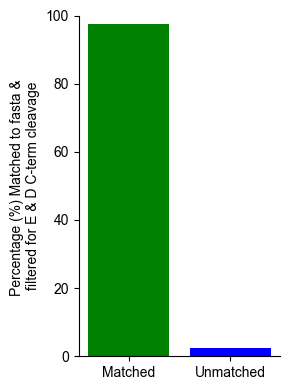

In [101]:
all_positions = big_df['Positions within proteins'].apply(lambda x: np.nan if isinstance(x, list) and len(x) == 0 else x) 

total_numbers_count = len(all_positions.dropna())
total_strings_count = len(big_df['matched_sequence'].dropna())

string_percentage = (total_strings_count / total_numbers_count) * 100 if total_numbers_count > 0 else 0
remaining_percentage = 100 - string_percentage
labels = ['Matched', 'Unmatched']
percentages = [string_percentage, remaining_percentage]

fig, ax = plt.subplots(figsize=(3,4))  #
ax.bar(labels, percentages, color=['green', 'blue'])
ax.set_title('')
ax.set_ylabel('Percentage (%) Matched to fasta & \nfiltered for E & D C-term cleavage')
ax.set_xlabel('')
ax.set_ylim(0, 100)  
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

file_path = fig_dir + "precent_fasta_match.pdf"
plt.tight_layout()
plt.savefig(file_path, transparent=True)
plt.show()

# AF plddt 

Very high (pLDDT > 90)
 Confident (90 > pLDDT > 70)
 Low (70 > pLDDT > 50)
 Very low (pLDDT < 50) 

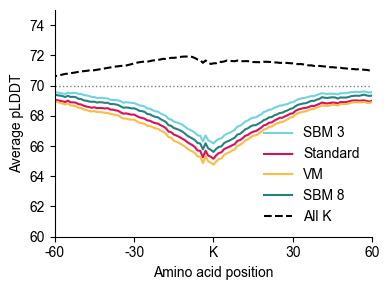

In [102]:
flattened = [
    tuple(sublist)
    for row in big_df['all_surr_pddlt']
    if isinstance(row, list)
    for sublist in row
    if sublist 
]

unique_flattened = set(flattened)
flattened_list_ref = [list(t) for t in unique_flattened]


datasets = ["SBM 3", "Standard", "VM", "SBM 8"]
fig, ax = plt.subplots(figsize=(4, 3))

for dataset in datasets:
    df = big_df[big_df['Dataset'] == dataset] 
    valid_lists = [list(t) for t in set(tuple(row) for row in df['pddlt'] if isinstance(row, list))]

    df_test = pd.DataFrame(valid_lists)
    df_test.replace('-', np.nan, inplace=True)
    df_test = df_test.apply(pd.to_numeric, errors='coerce')
    df_test_means = df_test.mean(skipna=True)

    num_positions = len(df_test_means)
    centered_positions = np.arange(-num_positions // 2, num_positions // 2)

    ax.plot(centered_positions, df_test_means, label=dataset, color=color_map[dataset])

df_test = pd.DataFrame(flattened_list_ref)
df_test.replace('-', np.nan, inplace=True)
df_test_means = df_test.mean(axis=0, skipna=True)

ax.axhline(y=70, color='grey', linestyle='dotted', linewidth=1)
ax.plot(centered_positions, df_test_means, label='All K', color='black', linestyle='dashed')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Amino acid position')
ax.set_ylabel('Average pLDDT')
ax.grid(False)
ax.legend(frameon=False)
ax.set_ylim(60, 75)
ax.set_xlim(-60, 60)
xticks = np.linspace(-60, 60, 5, dtype=int) 
xticks[len(xticks) // 2] = 0 
xtick_labels = [str(x) if x != 0 else 'K' for x in xticks]  # Replace 0 with 'K'
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
file_path = fig_dir + "av_plddt_with_K.pdf"
plt.tight_layout()
plt.savefig(file_path, transparent=True)
plt.show()

# Motif adherence

In [103]:
pattern = r'.{6}K\wE'  
anywhere_pattern = r'K\[su\][A-Z]E'

def calculate_motif_adherence(sequence_list, anywhere = False):
    if anywhere == False:
        total_sequences = len(sequence_list)
        print(total_sequences)
        matched_sequences = sum(1 for seq in sequence_list if re.search(pattern, seq))
        print(matched_sequences)
    if anywhere == True: 
        total_sequences = len(sequence_list)
        print(total_sequences)
        matched_sequences = sum(1 for seq in sequence_list if re.search(anywhere_pattern, seq))
        print(matched_sequences)

    print("Adherence: " + str((matched_sequences / total_sequences) * 100))
        
    return (matched_sequences / total_sequences) * 100

9411
2611
Adherence: 27.744129210498354
10504
2831
Adherence: 26.951637471439447
8883
2469
Adherence: 27.794663964876733
8346
2366
Adherence: 28.34890965732087
56356
6154
Adherence: 10.919866562566542


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/3442168321.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


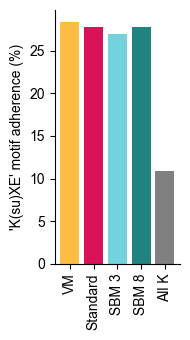

In [104]:
set_sbm8 = set(sequences_sbm8)
set_sbm3 = set(sequences_sbm3)
set_st = set(sequences_st)
set_0 = set(sequences_0)
flattened_sequences_ref = [item for sublist in sequences_ref for item in sublist]
flattened_sequences_ref = [trim_sequence(seq) for seq in flattened_sequences_ref]
set_ref = set(flattened_sequences_ref) - set_sbm8 - set_sbm3 - set_st - set_0 

adherence_sbm8 = calculate_motif_adherence(set(set_sbm8))
adherence_sbm3 = calculate_motif_adherence(set(set_sbm3))
adherence_st = calculate_motif_adherence(set(set_st))
adherence_vm = calculate_motif_adherence(set(set_0))
adherence_ref = calculate_motif_adherence(set_ref)

categories = ['VM', 'Standard', 'SBM 3', 'SBM 8','All K']
percentages = [adherence_vm, adherence_st, adherence_sbm3, adherence_sbm8, adherence_ref]

fig, ax = plt.subplots(figsize=(2, 3.5))

bars = ax.bar(
    categories, 
    percentages, 
    color=[color_map.get(category, 'grey') for category in categories], 
    width=0.8
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("'K(su)XE' motif adherence (%)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
file_path = fig_dir + "motif_adherence.pdf"
plt.tight_layout()
plt.savefig(file_path, transparent=True)
plt.show()


1799
402
Adherence: 22.345747637576434
178
40
Adherence: 22.47191011235955
8705
2429
Adherence: 27.903503733486502


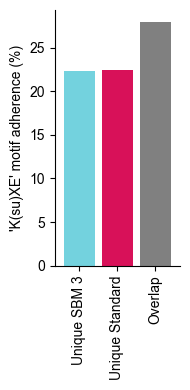

In [105]:
unique_to_sbm3 = set_sbm3.difference(set_st)
unique_to_st = set_st.difference(set_sbm3)
overlap = set_sbm3.intersection(set_st)

adherence_unique_sbm3 = calculate_motif_adherence(unique_to_sbm3)
adherence_unique_st = calculate_motif_adherence(unique_to_st)
adherence_overlap = calculate_motif_adherence(overlap)

categories = ['Unique SBM 3', 'Unique Standard', 'Overlap']
adherence_values = [adherence_unique_sbm3, adherence_unique_st, adherence_overlap]

grouped_data_motif = pd.DataFrame({
    'Dataset': categories,
    'Adherence (%)': adherence_values
}).set_index('Dataset')

fig, ax = plt.subplots(figsize=(2, 4))

bars = grouped_data_motif['Adherence (%)'].plot(
    kind='bar', 
    color=[color_map.get(dataset, 'grey') for dataset in grouped_data_motif.index], 
    ax=ax, 
    width=0.8
)

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("'K(su)XE' motif adherence (%)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

file_path = fig_dir + "motif_overlap.pdf"
plt.tight_layout()
plt.savefig(file_path, transparent=True)
plt.show()

# Benchmarking 


In [109]:
df_per = pd.read_csv(per_path3, delimiter="\t")

df_per_sig_q = df_per[df_per['q-value'] <= 0.01] # not needed 
df_filtered_sumo_per = df_per_sig_q[df_per_sig_q['peptide'].str.contains(r'\[su\]', na=False)] 
df_filtered_sumo_per_unique = df_filtered_sumo_per.drop_duplicates(subset=['peptide'])

df_filtered_sumo_per_merged = df_filtered_sumo_per_unique.merge(no_fdr_set, on='PSMId', how='left')

In [ ]:
def process_psm_file(psm_file, dataset_name):
    """Reads and processes a single psm.tsv file."""
    df_psm = pd.read_csv(psm_file, delimiter="\t")
    df_psm['dataset'] = dataset_name

    df_filtered = df_psm[~df_psm['Protein ID'].str.contains('rev_', na=False)]
    #df_filtered = df_psm[df_psm['Modified Peptide'].notna()]
    
    df_filtered_sumo = df_filtered[df_filtered['Modified Peptide'].str.contains(r'\[1089\]', na=False)]
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Protein ID'].str.contains('rev_', na=False)]
    
    # Remove duplicate sumo rows
    #df_filtered_sumo = df_filtered_sumo[~df_filtered_sumo['Assigned Modifications'].str.contains(r'(K\(960\.4301\)).*\1', regex=True)]
    df_unique_msfragger_sumo = df_filtered_sumo.drop_duplicates(subset=['Modified Peptide'])
    
    # Extract modification positions
    df_filtered_sumo['pos'] = df_filtered_sumo['Assigned Modifications'].str.extract(r'(\d+)(?=K\(960\.4301\))')
    
    return df_filtered, df_filtered_sumo, df_unique_msfragger_sumo

def process_folder(folder_path):
    """Processes all psm.tsv files in a folder and combines them into a single DataFrame."""
    all_dfs = []
    all_sumos = []
    all_unique = []
    
    for root, _, files in os.walk(folder_path):
        if "psm.tsv" in files:
            dataset_name = os.path.basename(root)
            psm_path = os.path.join(root, "psm.tsv")
            print(f"Processing: {psm_path}")
            psms, sumos, unique_sumo  = process_psm_file(psm_path, dataset_name)
            all_dfs.append(psms)
            all_sumos.append(sumos)
            all_unique.append(unique_sumo)
    
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df_s = pd.concat(all_sumos, ignore_index=True)
    combined_df_u = pd.concat(all_unique, ignore_index=True)
    
    return combined_df, combined_df_s, combined_df_u

msfragger_psms, msfragger_sumo, msfragger_unique_sumo = process_folder(msfragger_folder_path)

In [117]:
sel_msfragger_unique_sumo = msfragger_unique_sumo[msfragger_unique_sumo['dataset'] == 'MSFragger Percolator 3 p-ions']
sel_msfragger_sumo = msfragger_sumo[msfragger_sumo['dataset'] == 'MSFragger Percolator 3 p-ions']
sel_msfragger_psms = msfragger_psms[msfragger_psms['dataset'] == 'MSFragger Percolator 3 p-ions']

In [119]:
custom_order_b = ['MQ SBM 3 Percolator', 'MSFragger Percolator 8 p-ions', 'MSFragger Percolator 3 p-ions', 'MSFragger Percolator 0 p-ions']  # your desired order


/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/223385873.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  all_counts = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/223385873.py:6: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  all_counts = all_counts.append(dataset_counts)


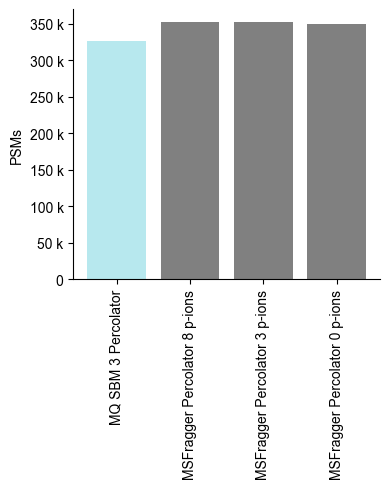

In [120]:
all_counts = pd.Series()
total_count = len(df_per_sig_q)
all_counts.loc["MQ SBM 3 Percolator"] = total_count 

dataset_counts = msfragger_psms['dataset'].value_counts()
all_counts = all_counts.append(dataset_counts)
all_counts = all_counts.reindex(custom_order_b)

fig, ax = plt.subplots(figsize=(4, 5))
bars = ax.bar(all_counts.index, all_counts.values, 
    color=[color_map.get(dataset, 'grey') for dataset in all_counts.index]
)

#for bar in bars:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('PSMs')
ax.set_title('')
ax.set_xticks(all_counts.index) 
ax.set_xticklabels(all_counts.index, rotation=90) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "nr_psms_wmsfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show() 

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2526433057.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_counts_unique = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/2526433057.py:7: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  filtered_counts_unique = filtered_counts_unique.append(dataset_counts)


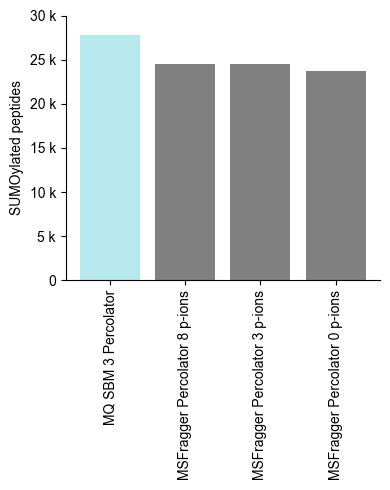

In [121]:
filtered_counts_unique = pd.Series()

total_count = len(df_filtered_sumo_per_unique)
filtered_counts_unique.loc["MQ SBM 3 Percolator"] = total_count # 

dataset_counts = msfragger_unique_sumo['dataset'].value_counts()
filtered_counts_unique = filtered_counts_unique.append(dataset_counts)
filtered_counts_unique = filtered_counts_unique.reindex(custom_order_b)

fig, ax = plt.subplots(figsize=(4, 5))
bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

#for bar in bars_un:
#    height = bar.get_height()
#    ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')
ax.set_xticks(filtered_counts_unique.index) 
ax.set_ylim(0, 30000)
ax.set_xticklabels(filtered_counts_unique.index, rotation=90) # rotation=45,  

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()

file_path = fig_dir + "all_unique_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/4180666226.py:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  filtered_counts_unique = pd.Series()
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/4180666226.py:8: FutureWarning: The series.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  filtered_counts_unique = filtered_counts_unique.append(dataset_counts)


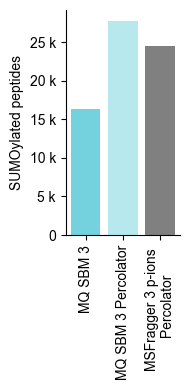

In [136]:
custom_order_c = ['SBM 3', 'MQ SBM 3 Percolator', 'MSFragger Percolator 3 p-ions']  

filtered_counts_unique = pd.Series()
total_count = len(df_filtered_sumo_per_unique)
filtered_counts_unique["MQ SBM 3 Percolator"] = total_count  

dataset_counts = sel_msfragger_unique_sumo['dataset'].value_counts()
filtered_counts_unique = filtered_counts_unique.append(dataset_counts)

filtered_counts_unique["SBM 3"] = len(filtered_big_df_unique[filtered_big_df_unique['Dataset'] == "SBM 3"])

filtered_counts_unique = filtered_counts_unique.reindex(custom_order_c)

fig, ax = plt.subplots(figsize=(2, 4))

bars_un = ax.bar(
    filtered_counts_unique.index, 
    filtered_counts_unique.values, 
    color=[color_map.get(dataset, 'grey') for dataset in filtered_counts_unique.index]
)

# Optionally, add text to the bars (commented out for now)
#for bar in bars_un:
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width() / 2.0, height, '%d' % int(height), ha='center', va='bottom', rotation= 90)

# Customize the plot
ax.set_xlabel('')
ax.set_ylabel('SUMOylated peptides')
ax.set_title('')

label_map = {
    "SBM 3": "MQ SBM 3",
    "MQ SBM 3 Percolator": "MQ SBM 3 Percolator",
    "MSFragger Percolator 3 p-ions": "MSFragger 3 p-ions \n Percolator"
}

ax.set_xticks(range(len(filtered_counts_unique)))
ax.set_xticklabels(
    [label_map.get(lbl, lbl) for lbl in filtered_counts_unique.index],
    rotation=90
)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
file_path = fig_dir + "unique_sumo_peptides_w_msfragger.pdf"
plt.savefig(file_path, transparent=True)
plt.show()

In [144]:
df_filtered_sumo_per_unique['sumoylated_peptides'] = df_filtered_sumo_per_unique['peptide'].str.replace(r'.', '', regex=True).str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)

sel_msfragger_u = msfragger_unique_sumo[msfragger_unique_sumo['dataset'] == 'MSFragger Percolator 3 p-ions']
sel_msfragger_u['sumoylated_peptides'] = sel_msfragger_u['Modified Peptide'].str.replace(r'\[1089\]', '[su]', regex=True).str.replace(r'\[43\]', '', regex=True).str.replace(r'\[147\]', '', regex=True)

/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/721315520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_sumo_per_unique['sumoylated_peptides'] = df_filtered_sumo_per_unique['peptide'].str.replace(r'.', '', regex=True).str.replace(r'\[ac\]', '', regex=True).str.replace(r'\[ox\]', '', regex=True)
/var/folders/xb/lqsp1s4j623fywqz4zpxf0v80000gn/T/ipykernel_71109/721315520.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sel_msfragger_u['sumoylated_peptides'] = sel_msfragger

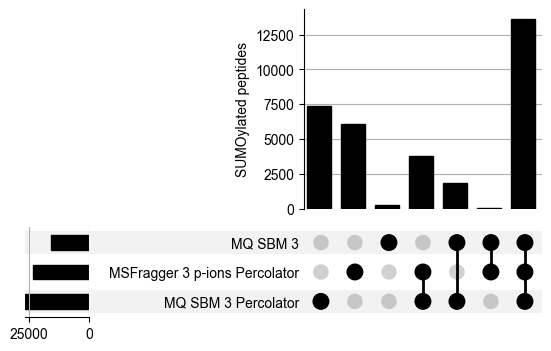

In [154]:
sbm3set_speps = set(sbm3set_speps)
mq_speps_per = set(df_filtered_sumo_per_unique['sumoylated_peptides'])
msfragger_speps = set(sel_msfragger_u['sumoylated_peptides'])

all_sequences = sbm3set_speps.union(mq_speps_per).union(msfragger_speps)
data = []

for sequence in all_sequences:
    in_sbm_3 = sequence in sbm3set_speps
    in_sbm_3_per = sequence in mq_speps_per
    in_msfrag = sequence in msfragger_speps

    data.append([in_sbm_3, in_sbm_3_per, in_msfrag, sequence])

df_overlap = pd.DataFrame(data, columns=['MQ SBM 3', 'MQ SBM 3 Percolator', 'MSFragger 3 p-ions Percolator', 'id'])
df_overlap.set_index(['MQ SBM 3', 'MQ SBM 3 Percolator', 'MSFragger 3 p-ions Percolator'], inplace=True)

ax_dict = UpSet(df_overlap, subset_size="count", min_subset_size=10, show_counts =False).plot() 
ax_dict["intersections"].set_ylabel("SUMOylated peptides")


for bar in ax_dict['intersections'].patches:
    bar.set_width(0.7)  
    bar.set_x(bar.get_x() - 0.15) 
    
plt.gcf().savefig(fig_dir + "upset_plot_speps_bench.pdf", format="pdf", transparent=True)